# Import packages

In [39]:
# %pip install sodapy
# %pip install geopandas
# %pip install ipywidgets

  Using cached ipywidgets-8.1.7-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
  Using cached widgetsnbextension-4.0.14-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.7-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl (216 kB)
Using cached widgetsnbextension-4.0.14-py3-none-any.whl (2.2 MB)
Using cached ipywidgets-8.1.7-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.15-py3-none-any.whl (216 kB)
Using cached widgetsnbextension-4.0.14-py3-none-any.whl (2.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip3 install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sodapy import Socrata
import json
import os
import geopandas as gpd
import requests
import shapely
env = os.environ

# Getting the data

In [3]:
# Settings
api_key = env.get("API_KEY")
app_token = env.get("APP_TOKEN")
secret_key = env.get("SECRET_KEY")

DATASET_ID = "kufs-yh3x"
limit = 100000
offset = 0

Filter = 'Manhattan'

client = Socrata("data.ny.gov", app_token = app_token)


In [4]:
# getting the data with api call
# all_results = []

# while True:
#     batch = client.get(
#         DATASET_ID,
#         where = "borough = 'Manhattan'",
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit

# data_df = pd.DataFrame(all_results)

# saving the data
# data_df.to_csv("Manhattan_Bus_data.csv")

# loading the data
data_df = pd.read_csv("Manhattan_Bus_data.csv", index_col = 0)

## GEOJSON Data

In [5]:
DATASET_ID = "pri4-ifjk"
limit = 10
offset = 0

all_results = []

## Getting the data
# while True:
#     batch = client.get(
#         DATASET_ID,
#         limit=limit,
#         offset=offset
#     )
#     if not batch:
#         break
#     all_results.extend(batch)
#     print(f"Downloaded {len(batch)} records (offset {offset})")
#     offset += limit


## Converting the results into features
# features = []

# for record in all_results:
#     feature = {
#         "type": "Feature",
#         "geometry": record["the_geom"],
#         "properties": {k: v for k, v in record.items() if k != "the_geom" and k != "zcta" and k != "label"}
#     }
#     features.append(feature)


# Create GeoDataFrame
# gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")
# gdf.to_file("geo_data_converted.geojson", driver="GeoJSON")

# loading the data
gdf = gpd.read_file("geo_data_converted.geojson")

## Creating point data

In [6]:
# Creating dataframe of points (keep original index)
points_df = data_df[["timepoint_stop_latitude", "timepoint_stop_longitude"]].copy()

# Ensure numeric
points_df["timepoint_stop_latitude"] = pd.to_numeric(points_df["timepoint_stop_latitude"], errors='coerce')
points_df["timepoint_stop_longitude"] = pd.to_numeric(points_df["timepoint_stop_longitude"], errors='coerce')

# Drop NaN coords but keep index
points_df = points_df.dropna()

# Create geometry (lon, lat order for Point)
points_df["geometry"] = [
    shapely.geometry.Point(lon, lat) 
    for lon, lat in zip(points_df["timepoint_stop_longitude"], points_df["timepoint_stop_latitude"])
]

# Convert to GeoDataFrame
gdf_points = gpd.GeoDataFrame(points_df, geometry='geometry', crs='EPSG:4326')

# Spatial join: find which ZIP polygon each point falls within
joined = gpd.sjoin(gdf_points, gdf[['modzcta', 'geometry']], how='left', predicate='within')

# Add ZIP code back to original data_df using the preserved index
data_df['zip_code'] = None  # initialize column
data_df.loc[joined.index, 'zip_code'] = joined['modzcta'].values

In [7]:
def _make_linestring(row):
    lat1 = row.get("timepoint_stop_latitude")
    lon1 = row.get("timepoint_stop_longitude")
    lat2 = row.get("next_timepoint_stop_latitude")
    lon2 = row.get("next_timepoint_stop_longitude")
    
    # Validate coordinates exist and are numeric
    try:
        lat1 = float(lat1) if lat1 is not None else None
        lon1 = float(lon1) if lon1 is not None else None
        lat2 = float(lat2) if lat2 is not None else None
        lon2 = float(lon2) if lon2 is not None else None
    except (ValueError, TypeError):
        return shapely.geometry.LineString()
    
    # Check for NaN or missing values
    if any(v is None or pd.isna(v) for v in [lat1, lon1, lat2, lon2]):
        return shapely.geometry.LineString()
    
    # Validate coordinate ranges
    if not (-90 <= lat1 <= 90 and -180 <= lon1 <= 180 and -90 <= lat2 <= 90 and -180 <= lon2 <= 180):
        return shapely.geometry.LineString()
    
    # LineString expects (lon, lat) order for proper GIS coordinates
    return shapely.geometry.LineString([(lon1, lat1), (lon2, lat2)])

# apply along rows (axis=1)
data_df["LineString"] = data_df.apply(_make_linestring, axis=1)

# Check for empty geometries
print(f"Total rows: {len(data_df)}")
print(f"Empty geometries: {(data_df['LineString'].length == 0).sum()}")
print(f"Valid geometries: {(data_df['LineString'].length > 0).sum()}")

# Cleaning the data

In [8]:
# chaging timestamp to datetime and making it the index - so I can filter later
data_df["timestamp"] = pd.to_datetime(data_df["timestamp"])
data_df.set_index("timestamp", inplace = True)

# Analyzing the data

In [9]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 606189 entries, 2025-03-01 12:00:00 to 2025-06-01 12:00:00
Data columns (total 25 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   year                              606189 non-null  int64  
 1   month                             606189 non-null  int64  
 2   day_of_week                       606189 non-null  object 
 3   hour_of_day                       606189 non-null  int64  
 4   route_id                          606189 non-null  object 
 5   direction                         606189 non-null  object 
 6   borough                           606189 non-null  object 
 7   route_type                        606189 non-null  object 
 8   stop_order                        606189 non-null  int64  
 9   timepoint_stop_id                 606189 non-null  int64  
 10  timepoint_stop_name               606189 non-null  object 
 11  timepoint_stop_lat

## Plotting the data

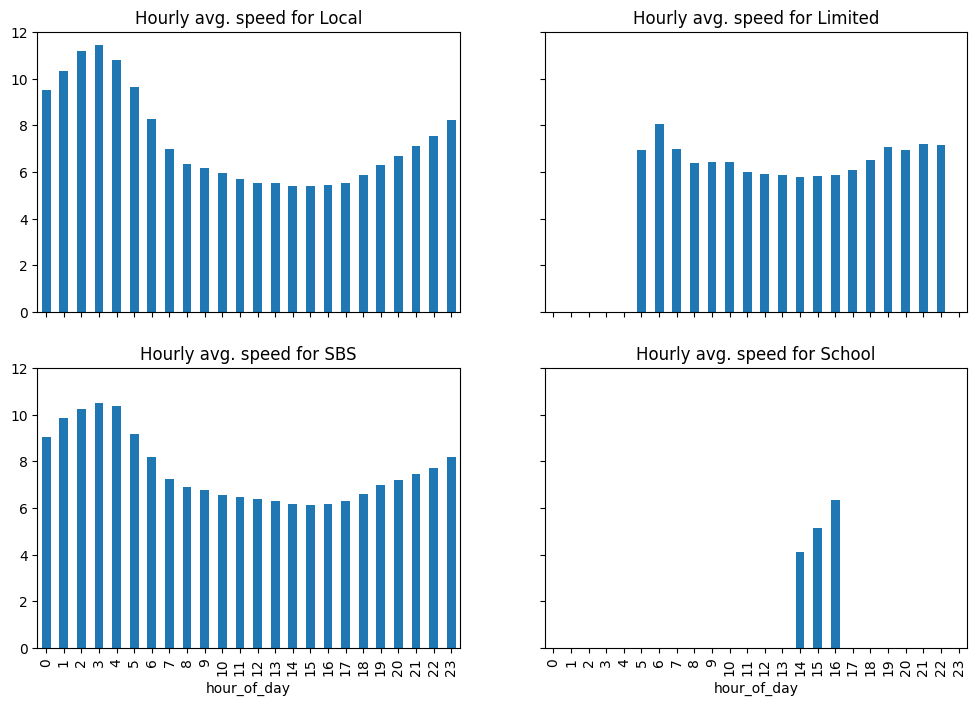

In [10]:
figs, axes = plt.subplots(2,2, figsize = (12,8), sharex = True, sharey = True)

options = list(data_df["route_type"].unique())
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    condition = options[i]
    subset = data_df[data_df["route_type"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


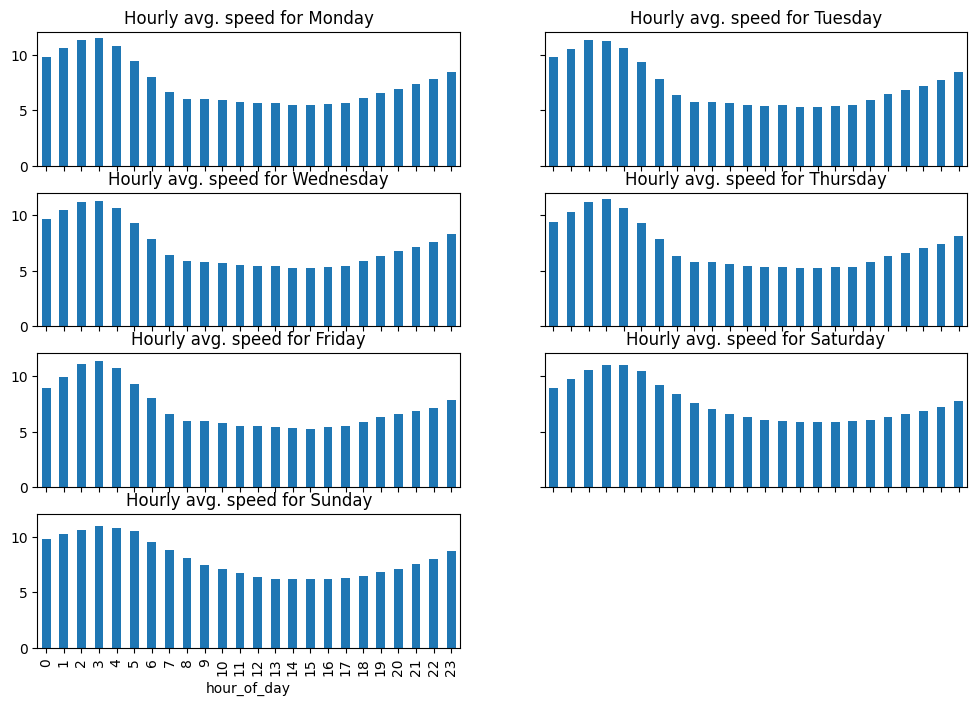

In [11]:
figs, axes = plt.subplots(4,2, figsize = (12,8), sharex = True, sharey = True)

options = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = list(range(24))

for i, ax in enumerate(axes.flatten()):
    if i > len(condition):
        ax.set_visible(False)
        break
    condition = options[i]
    subset = data_df[data_df["day_of_week"] == condition]
    subset.groupby(["hour_of_day"])["average_road_speed"].mean().reindex(hours).plot(kind = "bar", ax = ax)
    ax.set_title(f"Hourly avg. speed for {condition}")


# Plotting data on map

In [12]:
# The number of stops fluctuates
test = data_df[(data_df["route_id"] == "M4") & (data_df["month"] == 1)].sort_values(by = ["hour_of_day", "stop_order"])

test["stop_order"].sort_values().unique()

array([ 1,  2, 10, 13, 23, 25, 27, 28, 30, 33, 41, 45, 46, 47, 49, 50, 51,
       56, 61, 67, 72, 78])

In [13]:
data_df.groupby(["month", "day_of_week"]).size().head(10)

month  day_of_week
1      Friday          9804
       Monday          9610
       Saturday        9255
       Sunday          9015
       Thursday        9811
       Tuesday         9536
       Wednesday      10298
2      Friday         10485
       Monday          9963
       Saturday        9071
dtype: int64

In [35]:
import folium
import geopandas as gpd
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_bus_routes(data_df, month=None, weekday=None, route_id=None, hour = None):
    """
    Plot NYC bus routes with color indicating average speed.
    """

    # ---- Filter data ----
    df = data_df.copy()
    if month is not None:
        df = df[df["month"] == month]
    if weekday is not None:
        df = df[df["day_of_week"] == weekday]
    if route_id is not None:
        df = df[df["route_id"] == route_id]
    if hour is not None:
        df = df[df["hour_of_day"] == hour]

    if df.empty:
        print("No data found for given filters.")
        return None

    # ---- Convert to GeoDataFrame ----
    gdf = gpd.GeoDataFrame(df, geometry="LineString", crs="EPSG:4326")

    # ---- Compute speed range ----
    speeds = gdf["average_road_speed"].dropna()

    min_s, max_s = speeds.min(), speeds.max()
    norm = mcolors.Normalize(vmin=min_s, vmax=max_s)
    cmap = cm.get_cmap("RdYlGn")

    # ---- Initialize map ----
    m = folium.Map(location=[40.7831, -73.9712], zoom_start=12)

    # ---- Plot routes ----
    for _, row in gdf.iterrows():
        speed = row["average_road_speed"]
        
        color = mcolors.to_hex(cmap(norm(speed)))
        coords = [[lat, lon] for lat, lon in row["LineString"].coords]

        folium.PolyLine(
            locations=coords,
            color=color,
            weight=3,
            opacity=0.8,
            popup=f"{row['route_id']} | {speed:.1f} mph"
        ).add_to(m)

    return m


# Examples:
# Plot specific route M4 for January on Monday
m = plot_bus_routes(data_df, month=1, weekday="Tuesday", hour = 16, route_id=["M7", "M3"])
m



/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_32391/2305253574.py:29: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf = gdf[gdf.geometry.notna() & (gdf.geometry.length > 0)]
/var/folders/_d/ljvnpndd76v52vr16dysc7lr0000gn/T/ipykernel_32391/2305253574.py:43: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("RdYlGn")


In [36]:
# Save map to HTML file to view in browser (workaround for trust issues)
if m is not None:
    m.save("bus_routes_map.html")
    print("Map saved to bus_routes_map.html")
    print("Open this file in your browser to view the map")


Map saved to bus_routes_map.html
Open this file in your browser to view the map


## Interactive Map with Controls and Animation

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML
import time

# Get unique values for dropdowns
routes = sorted(data_df['route_id'].unique().tolist())
months = sorted(data_df['month'].unique().tolist())
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
hours = list(range(24))

# Create dropdown widgets
route_dropdown = widgets.Dropdown(
    options=['All Routes'] + routes,
    value='All Routes',
    description='Route:',
    style={'description_width': 'initial'}
)

month_dropdown = widgets.Dropdown(
    options=['All Months'] + months,
    value=1,
    description='Month:',
    style={'description_width': 'initial'}
)

weekday_dropdown = widgets.Dropdown(
    options=['All Weekdays'] + weekdays,
    value='Monday',
    description='Weekday:',
    style={'description_width': 'initial'}
)

hour_slider = widgets.IntSlider(
    value=12,
    min=0,
    max=23,
    step=1,
    description='Hour:',
    continuous_update=False,
    style={'description_width': 'initial'}
)

# Animation controls
play_button = widgets.Play(
    value=0,
    min=0,
    max=23,
    step=1,
    interval=1000,  # 1 second per frame
    description="Animate Hours",
    disabled=False
)

widgets.jslink((play_button, 'value'), (hour_slider, 'value'))

# Output widget for the map
output = widgets.Output()

def update_map(change=None):
    """Update the map based on dropdown selections"""
    with output:
        output.clear_output(wait=True)
        
        # Get values from widgets
        route = None if route_dropdown.value == 'All Routes' else route_dropdown.value
        month = None if month_dropdown.value == 'All Months' else month_dropdown.value
        weekday = None if weekday_dropdown.value == 'All Weekdays' else weekday_dropdown.value
        hour = hour_slider.value
        
        # Create the map
        m = plot_bus_routes(data_df, month=month, weekday=weekday, route_id=route, hour=hour)
        
        if m is not None:
            display(m)
        else:
            print("No data available for selected filters")

# Attach the update function to all widgets
route_dropdown.observe(update_map, names='value')
month_dropdown.observe(update_map, names='value')
weekday_dropdown.observe(update_map, names='value')
hour_slider.observe(update_map, names='value')

# Create layout
controls = widgets.VBox([
    widgets.HBox([route_dropdown, month_dropdown, weekday_dropdown]),
    widgets.HBox([play_button, hour_slider])
])

# Display the interface
display(controls)
display(output)

# Initial map
update_map()


Output()

### Alternative: Create Multi-Hour HTML Animation

This creates a single HTML file with all 24 hours that you can cycle through in your browser.

In [ ]:
def create_animated_map_html(data_df, filename="bus_animation.html", 
                             month=1, weekday="Monday", route_id=None):
    """
    Create an HTML file with animated bus routes cycling through 24 hours.
    Includes dropdown controls for route, month, and weekday.
    """
    
    # Get all unique values for dropdowns
    all_routes = sorted(data_df['route_id'].unique().tolist())
    all_months = sorted(data_df['month'].unique().tolist())
    all_weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    
    # Generate maps for each hour
    print("Generating maps for each hour...")
    hour_maps_html = {}
    
    for hour in range(24):
        print(f"  Hour {hour}...", end=" ")
        m = plot_bus_routes(data_df, month=month, weekday=weekday, 
                           route_id=route_id, hour=hour)
        
        if m is not None:
            # Get the map HTML
            map_html = m._repr_html_()
            hour_maps_html[hour] = map_html
            print("✓")
        else:
            hour_maps_html[hour] = "<p>No data for this hour</p>"
            print("✗")
    
    # Create the complete HTML with controls
    html_template = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>NYC Bus Routes Animation</title>
        <style>
            body {{
                font-family: Arial, sans-serif;
                margin: 0;
                padding: 0;
            }}
            #controls {{
                position: fixed;
                top: 10px;
                left: 10px;
                background: white;
                padding: 15px;
                border: 2px solid #333;
                border-radius: 5px;
                z-index: 10000;
                box-shadow: 0 2px 10px rgba(0,0,0,0.3);
            }}
            .control-group {{
                margin-bottom: 10px;
            }}
            label {{
                display: inline-block;
                width: 80px;
                font-weight: bold;
            }}
            select, input {{
                width: 150px;
                padding: 5px;
                margin-left: 10px;
            }}
            #hour-display {{
                font-size: 24px;
                font-weight: bold;
                text-align: center;
                margin: 10px 0;
                color: #0066cc;
            }}
            button {{
                padding: 10px 20px;
                margin: 5px;
                cursor: pointer;
                background: #0066cc;
                color: white;
                border: none;
                border-radius: 3px;
                font-size: 14px;
            }}
            button:hover {{
                background: #0052a3;
            }}
            #map-container {{
                width: 100%;
                height: 100vh;
            }}
            .map-frame {{
                display: none;
                width: 100%;
                height: 100%;
            }}
            .map-frame.active {{
                display: block;
            }}
        </style>
    </head>
    <body>
        <div id="controls">
            <h3 style="margin-top: 0;">NYC Bus Routes</h3>
            
            <div class="control-group">
                <label>Route:</label>
                <select id="route-select">
                    <option value="all">All Routes</option>
                    {''.join(f'<option value="{r}">{r}</option>' for r in all_routes)}
                </select>
            </div>
            
            <div class="control-group">
                <label>Month:</label>
                <select id="month-select">
                    {''.join(f'<option value="{m}" {"selected" if m == month else ""}>{m}</option>' for m in all_months)}
                </select>
            </div>
            
            <div class="control-group">
                <label>Weekday:</label>
                <select id="weekday-select">
                    {''.join(f'<option value="{w}" {"selected" if w == weekday else ""}>{w}</option>' for w in all_weekdays)}
                </select>
            </div>
            
            <div id="hour-display">Hour: 0</div>
            
            <input type="range" id="hour-slider" min="0" max="23" value="0" 
                   style="width: 100%;" oninput="updateHour(this.value)">
            
            <div style="text-align: center; margin-top: 10px;">
                <button onclick="playAnimation()">▶ Play</button>
                <button onclick="pauseAnimation()">⏸ Pause</button>
                <button onclick="resetAnimation()">⏮ Reset</button>
            </div>
            
            <button onclick="reloadData()" 
                    style="width: 100%; margin-top: 10px; background: #28a745;">
                🔄 Apply Filters
            </button>
        </div>
        
        <div id="map-container">
            {' '.join(f'<div class="map-frame" id="hour-{h}" {"class=\\"map-frame active\\"" if h == 0 else ""}>{html}</div>' 
                      for h, html in hour_maps_html.items())}
        </div>
        
        <script>
            let currentHour = 0;
            let animationInterval = null;
            
            function updateHour(hour) {{
                currentHour = parseInt(hour);
                document.getElementById('hour-display').textContent = 'Hour: ' + currentHour;
                document.getElementById('hour-slider').value = currentHour;
                
                // Hide all maps
                document.querySelectorAll('.map-frame').forEach(frame => {{
                    frame.classList.remove('active');
                }});
                
                // Show current hour map
                document.getElementById('hour-' + currentHour).classList.add('active');
            }}
            
            function playAnimation() {{
                pauseAnimation();  // Clear any existing interval
                animationInterval = setInterval(() => {{
                    currentHour = (currentHour + 1) % 24;
                    updateHour(currentHour);
                }}, 1000);  // Change every 1 second
            }}
            
            function pauseAnimation() {{
                if (animationInterval) {{
                    clearInterval(animationInterval);
                    animationInterval = null;
                }}
            }}
            
            function resetAnimation() {{
                pauseAnimation();
                updateHour(0);
            }}
            
            function reloadData() {{
                const route = document.getElementById('route-select').value;
                const month = document.getElementById('month-select').value;
                const weekday = document.getElementById('weekday-select').value;
                
                alert('Note: To apply new filters, you need to regenerate the HTML file from the notebook.\\n\\n' +
                      'Selected: Route=' + route + ', Month=' + month + ', Weekday=' + weekday);
            }}
        </script>
    </body>
    </html>
    """
    
    # Save to file
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(html_template)
    
    print(f"\n✅ Animation saved to {filename}")
    print(f"Open this file in your browser to view the animated map!")
    return filename

# Example usage:
# Create animation for route M7 on Tuesday in January
filename = create_animated_map_html(
    data_df, 
    filename="bus_animation_interactive.html",
    month=1, 
    weekday="Monday", 
    route_id=None  # Set to specific route like "M7" or None for all routes
)
